In [ ]:
from google.colab import drive
import pandas as pd
import pickle
import json
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import umap
from google.colab import files
import hdbscan
from sklearn.preprocessing import RobustScaler
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
 !pip install catboost -q
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
import shap
from sklearn.preprocessing import LabelEncoder



In [ ]:
#Cargar base df_model
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
modelo = pd.read_csv(file_name)
print(modelo.shape)
modelo.head()


Saving df_model.csv to df_model (1).csv
(29090, 36)


,customerID,n_buy,total_units_buy,avg_units_buy,total_value_buy,avg_value_buy,avg_profit_buy,profit_std_buy,n_assets_buy,n_categories_buy,...,avg_days_between_ops,n_transactions,buy_sell_ratio,net_units,net_value,risk_exposure,profitability_diff,riskLevel,investmentCapacity,customerType
0,00017496858921195E5A,80,146144.000,1826.800000,379542.059000,4744.275738,1.212326,1.485005,13,1,...,9.529412,124.0,1.777778,25117.000,30633.105000,728451.013000,0.145671,Aggressive,CAP_GT300K,Professional
1,00024864C985E72167A0,1,382.845,382.845000,4999.993985,4999.993985,0.029414,NaN,1,1,...,NaN,1.0,1.000000,382.845,4999.993985,4999.993985,NaN,Predicted_Conservative,Predicted_CAP_LT30K,Mass
2,0004718496C71D464F57,24,63176.000,2632.333333,356998.040000,14874.918333,-0.111018,0.807507,14,2,...,81.500000,36.0,1.846154,11040.000,283881.745000,430114.335000,-0.073759,Predicted_Conservative,Predicted_CAP_80K_300K,Mass
3,000676D07A4CF7526ECB,1,496.085,496.085000,4962.784731,4962.784731,0.002570,NaN,1,1,...,NaN,1.0,1.000000,496.085,4962.784731,4962.784731,NaN,Income,CAP_30K_80K,Mass
4,000900E880281981624D,1,7.000,7.000000,700.000000,700.000000,-0.160333,NaN,1,1,...,NaN,1.0,1.000000,7.000,700.000000,700.000000,NaN,Balanced,CAP_LT30K,Mass


In [ ]:
modelo = modelo[modelo['recency_days'] <= 365].copy()
print(f"Clientes para perfilar: {len(modelo):,}")
# 1. Crear variables indicadoras
modelo['es_vendedor'] = (modelo['n_sell'] > 0).astype(int)
modelo['vendedor_unico'] = (modelo['n_sell'] == 1).astype(int)
modelo['comprador_unico'] = (modelo['n_buy'] == 1).astype(int)


# Imputar 0 a los clientes de múltiples operaciones en mismo día
mask_misma_fecha = (modelo['avg_days_between_ops'].isnull() &
                    (modelo['n_buy'] + modelo['n_sell'] > 1))
modelo.loc[mask_misma_fecha, 'avg_days_between_ops'] = 0

Clientes para perfilar: 12,613


In [ ]:
modelo.describe()

,buy_sell_ratio,asset_diversification,recency_days,risk_exposure,activity_days,avg_profit_buy,n_buy,n_sell,profit_std_buy,n_categories_buy,n_categories_sell,category_diversification,avg_days_between_ops,es_vendedor,vendedor_unico,comprador_unico
count,12613.000000,12613.000000,12613.000000,1.261300e+04,12613.000000,12613.000000,12613.000000,12613.000000,8307.000000,12613.000000,12613.000000,12613.000000,11662.000000,12613.000000,12613.000000,12613.000000
mean,1.609046,4.644097,170.247522,1.953582e+05,1211.358281,0.275639,14.766986,9.859431,0.671931,1.159359,0.843416,1.159359,650.080973,0.790454,0.287085,0.341394
std,2.490428,6.943050,111.633162,1.434680e+06,634.246410,1.292876,61.579613,44.823734,1.222707,0.414195,0.496079,0.414195,669.943621,0.407001,0.452419,0.474196
min,0.015625,1.000000,0.000000,1.472000e-01,0.000000,-0.997241,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,1.000000,68.000000,2.122500e+03,678.000000,-0.052797,1.000000,1.000000,0.083439,1.000000,1.000000,1.000000,81.666667,1.000000,0.000000,0.000000
50%,1.000000,2.000000,163.000000,1.018800e+04,1527.000000,0.156666,3.000000,2.000000,0.397670,1.000000,1.000000,1.000000,276.583333,1.000000,0.000000,0.000000
75%,1.833333,5.000000,279.000000,5.275014e+04,1693.000000,0.262965,9.000000,5.000000,0.871147,1.000000,1.000000,1.000000,1497.000000,1.000000,1.000000,1.000000
max,74.000000,124.000000,365.000000,5.055503e+07,1793.000000,30.000000,4047.000000,2241.000000,20.552028,3.000000,3.000000,3.000000,1793.000000,1.000000,1.000000,1.000000


In [ ]:
# Lista de variables
todas_las_variables = [
    'buy_sell_ratio',
    'asset_diversification',
    'recency_days',
    'risk_exposure',
    'activity_days',
    'avg_profit_buy',
    'n_buy',
    'n_sell',
    'profit_std_buy',
    'n_categories_buy',
    'n_categories_sell',
    'category_diversification',
    'avg_days_between_ops',
    "investmentCapacity",
   "customerType",
   "es_vendedor",
   "vendedor_unico",
   "comprador_unico"
]

# Filtrar la base de datos
modelo = modelo[todas_las_variables].copy()

Definir funcion para transformacion logaritmica

In [ ]:
def safe_log_transform(df, cols):

    df_log = df.copy()
    for col in cols:
        df_log[col] = np.sign(df_log[col]) * np.log1p(np.abs(df_log[col]))
    return df_log

In [ ]:
vars_trans = [
    'buy_sell_ratio', 'asset_diversification', 'recency_days',
    'risk_exposure', 'activity_days', 'avg_profit_buy',
    'n_buy', 'n_sell', 'profit_std_buy', 'n_categories_buy',
    'n_categories_sell', 'category_diversification','avg_days_between_ops'
]


In [ ]:
modelo_log = safe_log_transform(modelo, vars_trans)

Definir variables para cluster

In [ ]:
features_cluster = [
    # Variables de ratio y diversificación
    'buy_sell_ratio',
    'asset_diversification',

    # Variables temporales
    'recency_days',"activity_days",

    # Variable de volumen
    'risk_exposure']


Algoritmo UMAP

In [ ]:
X_cluster = modelo_log[features_cluster].copy()

# 1. Escalado robusto para UMAP
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 2. UMAP:
reducer = umap.UMAP(
    n_neighbors=20,
    n_components=3,
    min_dist=0.0,
    metric='euclidean',
    random_state=42
)
X_umap = reducer.fit_transform(X_scaled)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Metricas UMAP

In [ ]:
from sklearn.manifold import trustworthiness

k = 20
tw = trustworthiness(X_scaled, X_umap, n_neighbors=k)
print(f" Trustworthiness (k={k}): {tw:.3f}")

✅ Trustworthiness (k=20): 0.996


In [ ]:
k = 20
# Vecinos en alta dimensión
nn_high = NearestNeighbors(n_neighbors=k).fit(X_scaled)
_, idx_high = nn_high.kneighbors()

# Vecinos en baja dimensión
nn_low = NearestNeighbors(n_neighbors=k).fit(X_umap)
_, idx_low = nn_low.kneighbors()

continuities = []
for i in range(len(X_scaled)):
    true_neighbors = set(idx_high[i])
    emb_neighbors  = set(idx_low[i])
    cont = len(true_neighbors & emb_neighbors) / len(true_neighbors)
    continuities.append(cont)

mean_continuity = np.mean(continuities)
print(f" Continuity (k={k}): {mean_continuity:.3f}")

✅ Continuity (k=20): 0.587


Grafico en 3d

In [ ]:
df_plot = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])

fig = px.scatter_3d(
    df_plot,
    x='UMAP1', y='UMAP2', z='UMAP3',
    title='UMAP 3D',
    opacity=0.5
)
fig.update_traces(marker=dict(size=2))
fig.show()

Implementación HDBSCAN

In [ ]:
# 3. HDBSCAN en el espacio UMAP
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=500,
    min_samples=15,
    metric='euclidean',
    cluster_selection_method='eom',
    cluster_selection_epsilon=0,
    prediction_data=True
)

labels = clusterer.fit_predict(X_umap)

# 4. Resultados
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_ruido    = (labels == -1).sum()

print(f"Clusters encontrados : {n_clusters}")
print(f"Clientes en ruido    : {n_ruido:,}  ({n_ruido/len(labels)*100:.1f}%)")
for c in sorted(set(labels)):
    n   = (labels == c).sum()
    pct = n / len(labels) * 100
    tag = "ruido" if c == -1 else f"cluster {c}"
    print(f"  {tag:12s}  {n:>6,}  ({pct:5.1f}%)")

Clusters encontrados : 4
Clientes en ruido    : 356  (2.8%)
  ruido            356  (  2.8%)
  cluster 0      3,108  ( 24.6%)
  cluster 1        615  (  4.9%)
  cluster 2      5,043  ( 40.0%)
  cluster 3      3,491  ( 27.7%)


Caracterización del perfil

Tipos de datos en perfil_real:
cluster_visual
0        float64
1        float64
2        float64
3        float64
Ruido    float64
dtype: object

¿Hay NaN?: 0

═══ MEDIANAS POR CLUSTER EN ESCALA ORIGINAL ═══
cluster_visual                0       1          2          3    Ruido
buy_sell_ratio            0.500     1.0      1.024      2.000    1.000
asset_diversification     1.000     1.0      4.000      3.000    1.000
recency_days            191.000   153.0    135.000    148.000  313.000
risk_exposure          2338.845  2600.0  32844.660  14411.013  880.671
activity_days          1599.000     0.0   1648.000    476.000    0.000

═══ VARIABLES BINARIAS ═══
                es_vendedor  vendedor_unico  comprador_unico
cluster_visual                                              
0                     100.0            83.5             97.5
1                       0.2             0.2             98.4
2                      99.6             8.6              0.7
3                      52.4      

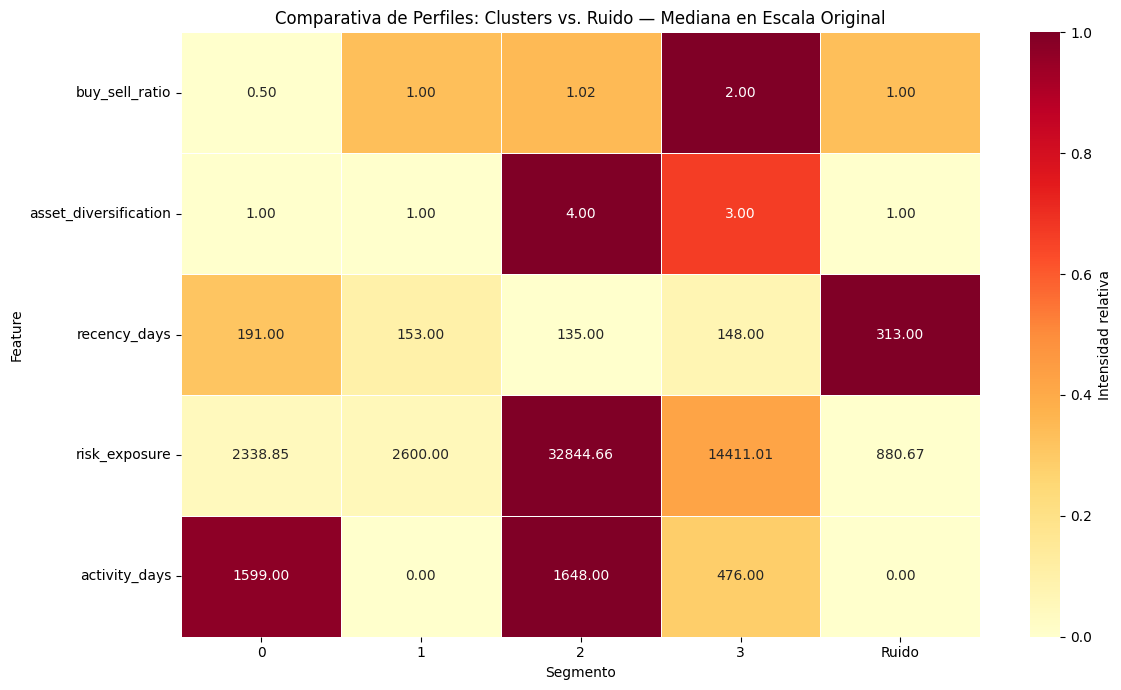

In [ ]:
modelo_log['cluster_visual'] = modelo_log['cluster_riesgo'].astype(str).replace('-1', 'Ruido')
order = sorted(modelo_log['cluster_visual'].unique())
perfil_mediana = modelo_log.groupby('cluster_visual')[features_cluster].median().T
perfil_mediana = perfil_mediana[order]
perfil_real = perfil_mediana.copy().astype(float)

for var in perfil_real.index:
    valores = perfil_real.loc[var].astype(float)
    perfil_real.loc[var] = np.sign(valores) * np.expm1(np.abs(valores))

# Verificación
print("Tipos de datos en perfil_real:")
print(perfil_real.dtypes)
print(f"\n¿Hay NaN?: {perfil_real.isna().sum().sum()}")

print("\n═══ MEDIANAS POR CLUSTER EN ESCALA ORIGINAL ═══")
print(perfil_real.round(3))


# Variables binarias
print("\n═══ VARIABLES BINARIAS ═══")
binarias = ['es_vendedor', "vendedor_unico", "comprador_unico"]
print(modelo_log.groupby('cluster_visual')[binarias].mean().round(3) * 100)

# Normalización para heatmap
perfil_min = perfil_real.min(axis=1).values.reshape(-1, 1)
perfil_max = perfil_real.max(axis=1).values.reshape(-1, 1)
perfil_range = perfil_max - perfil_min
perfil_range[perfil_range == 0] = 1

perfil_norm = pd.DataFrame(
    (perfil_real.values - perfil_min) / perfil_range,
    index=perfil_real.index,
    columns=perfil_real.columns
)

print(f"\nRango de perfil_norm: [{perfil_norm.min().min():.3f}, {perfil_norm.max().max():.3f}]")

#  Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(
    perfil_norm.astype(float),
    annot=perfil_real.round(2).values,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Intensidad relativa'},
    xticklabels=perfil_real.columns,
    yticklabels=perfil_real.index
)

plt.title('Comparativa de Perfiles: Clusters vs. Ruido — Mediana en Escala Original')
plt.xlabel('Segmento')
plt.ylabel('Feature')
plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/heatmap_clusters.png",
            #dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Metricas HDBSCAN

Persistencia

In [ ]:
persistencias = clusterer.cluster_persistence_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_ruido    = (labels == -1).sum()
print(f"Clusters encontrados : {n_clusters}")
print(f"Clientes en ruido    : {n_ruido:,}  ({n_ruido/len(labels)*100:.1f}%)")
print("-" * 65)
for c in sorted(set(labels)):
    n   = (labels == c).sum()
    pct = n / len(labels) * 100

    if c == -1:
        tag = "ruido"
        print(f"  {tag:12s}  {n:>6,}  ({pct:5.1f}%)  │  Persistencia: N/A")
    else:
        tag = f"cluster {c}"

        p_val = persistencias[c]
        print(f"  {tag:12s}  {n:>6,}  ({pct:5.1f}%)  │  Persistencia: {p_val:.4f}")

Clusters encontrados : 4
Clientes en ruido    : 356  (2.8%)
-----------------------------------------------------------------
  ruido            356  (  2.8%)  │  Persistencia: N/A
  cluster 0      3,108  ( 24.6%)  │  Persistencia: 0.3871
  cluster 1        615  (  4.9%)  │  Persistencia: 0.0228
  cluster 2      5,043  ( 40.0%)  │  Persistencia: 0.5817
  cluster 3      3,491  ( 27.7%)  │  Persistencia: 0.5688


Pertencia a cada cluster

In [ ]:
modelo_log['probabilidad_cluster'] = clusterer.probabilities_
resumen_probabilidades = modelo_log.groupby('cluster_riesgo')['probabilidad_cluster'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)
print("═══ ESTADÍSTICAS DE PROBABILIDAD DE PERTENENCIA POR CLUSTER ═══")
print(resumen_probabilidades.round(4))

═══ ESTADÍSTICAS DE PROBABILIDAD DE PERTENENCIA POR CLUSTER ═══
                count    mean  median     min  max
cluster_riesgo                                    
-1                356  0.0000  0.0000  0.0000  0.0
 0               3108  0.8500  1.0000  0.1470  1.0
 1                615  1.0000  1.0000  1.0000  1.0
 2               5043  0.8612  0.9820  0.3144  1.0
 3               3491  0.7003  0.7609  0.1693  1.0


Mapeo de nombres a los clusters

In [ ]:
mapping_nombres = {
    'Ruido': 'Inversor de huella latente',
    '1': 'Inversor de compra única',
    '2': 'Inversor de cartera dinámica',
    '3': 'Inversor de cartera en crecimiento',
    '0': 'Inversor de ciclo único'
}

modelo_log['segmento_final'] = modelo_log['cluster_visual'].map(mapping_nombres)

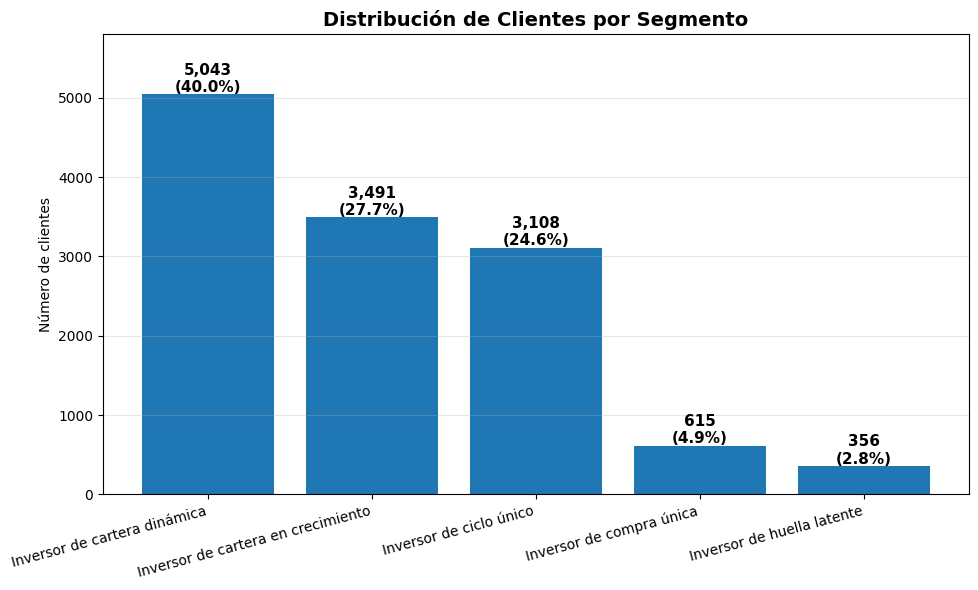

In [ ]:
dist = modelo_log['segmento_final'].value_counts()


fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(dist.index, dist.values)
# Anotar valor y porcentaje sobre cada barra
for barra, valor in zip(barras, dist.values):
    pct = valor / dist.sum() * 100
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 30,
            f'{valor:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Distribución de Clientes por Segmento', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de clientes')
ax.set_ylim(0, dist.max() * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

Cluster en representacion UMAP

In [ ]:

df_plot = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_plot['cluster_visual'] = modelo_log['cluster_visual'].values
orden_leyenda = sorted(df_plot['cluster_visual'].unique())
fig = px.scatter_3d(
    df_plot,
    x='UMAP1', y='UMAP2', z='UMAP3',
    color='cluster_visual',
    title='Proyección UMAP 3D — Visualización de Clusters',
    opacity=0.6,
    category_orders={'cluster_visual': orden_leyenda}
)

fig.update_traces(marker=dict(size=2))

fig.update_layout(
    legend_title_text='Segmentos',
    margin=dict(l=0, r=0, b=0, t=40)
)
fig.show()

Codificacion de las variables categoricas con problemas

In [ ]:
mapa_capacity = {
    'CAP_LT30K'            : 'Bajo',
    'Predicted_CAP_LT30K'  : 'Bajo',
    'CAP_30K_80K'          : 'Medio',
    'Predicted_CAP_30K_80K': 'Medio',
    'CAP_80K_300K'         : 'Medio',
    'Predicted_CAP_80K_300K': 'Medio',
    'CAP_GT300K'           : 'Alto',
    'Predicted_CAP_GT300K' : 'Alto',
    'Not_Available'        : 'Alto',
}

modelo_log['cap_recodificada'] = modelo_log['investmentCapacity'].map(mapa_capacity)

# customerType

mapa_type = {
    'Mass'        : 'Mass',
    'Premium'     : 'Premium',
    'Professional': 'Otros',
    'Inactive'    : 'Otros',
    'Legal Entity': 'Otros',
}

modelo_log['type_recodificado'] = modelo_log['customerType'].map(mapa_type)

# ── Verificar proporciones ──
print(modelo_log['cap_recodificada'].value_counts(normalize=True).round(3))
print()
print(modelo_log['type_recodificado'].value_counts(normalize=True).round(3))

cap_recodificada
Bajo     0.563
Medio    0.392
Alto     0.045
Name: proportion, dtype: float64

type_recodificado
Mass       0.573
Premium    0.373
Otros      0.054
Name: proportion, dtype: float64


Preparacion de datos para aplicacion del modelo subrogante

Preparacion para random forest

In [ ]:
# 1. Variables numéricas
features_a_revertir = [
    'buy_sell_ratio', 'asset_diversification', 'recency_days',
    'risk_exposure', 'avg_profit_buy',
    'n_buy', 'n_sell', 'profit_std_buy',
    'n_categories_buy', 'n_categories_sell', 'category_diversification',
    'activity_days', 'avg_days_between_ops'
]

vars_con_signo = ['buy_sell_ratio']
vars_sin_signo = [
    'asset_diversification', 'recency_days', 'risk_exposure',
    'n_buy', 'n_sell', 'profit_std_buy',
    'n_categories_buy', 'n_categories_sell', 'category_diversification',
    'activity_days', 'avg_profit_buy','avg_days_between_ops'
]

cols_con_nans = ['profit_std_buy', 'avg_days_between_ops']


X_num = modelo_log[features_a_revertir].copy()

for col in vars_con_signo:
    X_num[col] = np.sign(X_num[col]) * np.expm1(np.abs(X_num[col]))

for col in vars_sin_signo:
    X_num[col] = np.expm1(X_num[col])

X_num[cols_con_nans] = X_num[cols_con_nans].fillna(-1)

# Variables binarias

X_bin = modelo_log[['es_vendedor', 'vendedor_unico', 'comprador_unico']].copy()

#One-Hot Encoding.
X_cat_encoded = pd.get_dummies(
    modelo_log[['type_recodificado', 'cap_recodificada']],
    columns=['type_recodificado', 'cap_recodificada'],
    drop_first=False,
    dtype=int
)


X_final_rf = pd.concat([X_num, X_bin, X_cat_encoded], axis=1)

y = modelo_log['segmento_final']

print(X_final_rf.dtypes)
print(f"\nTamaño: {X_final_rf.shape}")

buy_sell_ratio               float64
asset_diversification        float64
recency_days                 float64
risk_exposure                float64
avg_profit_buy               float64
n_buy                        float64
n_sell                       float64
profit_std_buy               float64
n_categories_buy             float64
n_categories_sell            float64
category_diversification     float64
activity_days                float64
avg_days_between_ops         float64
es_vendedor                    int64
vendedor_unico                 int64
comprador_unico                int64
type_recodificado_Mass         int64
type_recodificado_Otros        int64
type_recodificado_Premium      int64
cap_recodificada_Alto          int64
cap_recodificada_Bajo          int64
cap_recodificada_Medio         int64
dtype: object

Tamaño: (12613, 22)


Preparacion para catboost

In [ ]:
features_a_revertir = [
    'buy_sell_ratio', 'asset_diversification', 'recency_days',
    'risk_exposure', 'avg_profit_buy',
    'n_buy', 'n_sell', 'profit_std_buy',
    'n_categories_sell', 'category_diversification',
    'activity_days', 'avg_days_between_ops'
]

vars_con_signo = ['buy_sell_ratio']
vars_sin_signo = [
    'asset_diversification', 'recency_days', 'risk_exposure',
    'n_buy', 'n_sell', 'profit_std_buy',
    'n_categories_sell', 'category_diversification',
    'activity_days', 'avg_profit_buy','avg_days_between_ops'
]

X_num = modelo_log[features_a_revertir].copy()

for col in vars_con_signo:
    X_num[col] = np.sign(X_num[col]) * np.expm1(np.abs(X_num[col]))

for col in vars_sin_signo:
    X_num[col] = np.expm1(X_num[col])


# Variables binarias

X_bin = modelo_log[['es_vendedor', 'vendedor_unico', 'comprador_unico']].copy()

# Variables categóricas recodificadas
X_cat = modelo_log[['type_recodificado', 'cap_recodificada']].copy()
X_cat['type_recodificado'] = X_cat['type_recodificado'].astype('category')
X_cat['cap_recodificada'] = X_cat['cap_recodificada'].astype('category')
X_final_catboost = pd.concat([X_num, X_bin, X_cat], axis=1)

y = modelo_log['segmento_final']

print(X_final_catboost.dtypes)
print(f"\nTamaño: {X_final_catboost.shape}")

buy_sell_ratio               float64
asset_diversification        float64
recency_days                 float64
risk_exposure                float64
avg_profit_buy               float64
n_buy                        float64
n_sell                       float64
profit_std_buy               float64
n_categories_sell            float64
category_diversification     float64
activity_days                float64
avg_days_between_ops         float64
es_vendedor                    int64
vendedor_unico                 int64
comprador_unico                int64
type_recodificado           category
cap_recodificada            category
dtype: object

Tamaño: (12613, 17)


Division del conjunto de datos en entrenamiento y test

Random forest

Iniciando la búsqueda en rejilla...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ...criterion=gini, max_depth=None, n_estimators=100; total time=   2.1s
[CV] END ...criterion=gini, max_depth=None, n_estimators=100; total time=   2.2s
[CV] END ...criterion=gini, max_depth=None, n_estimators=100; total time=   2.3s
[CV] END ...criterion=gini, max_depth=None, n_estimators=200; total time=   3.4s
[CV] END ...criterion=gini, max_depth=None, n_estimators=200; total time=   3.1s
[CV] END ...criterion=gini, max_depth=None, n_estimators=200; total time=   5.5s
[CV] END .....criterion=gini, max_depth=10, n_estimators=100; total time=   2.9s
[CV] END .....criterion=gini, max_depth=10, n_estimators=100; total time=   1.4s
[CV] END .....criterion=gini, max_depth=10, n_estimators=100; total time=   1.3s
[CV] END .....criterion=gini, max_depth=10, n_estimators=200; total time=   2.7s
[CV] END .....criterion=gini, max_depth=10, n_estimators=200; total time=   2.6s
[CV] END ....

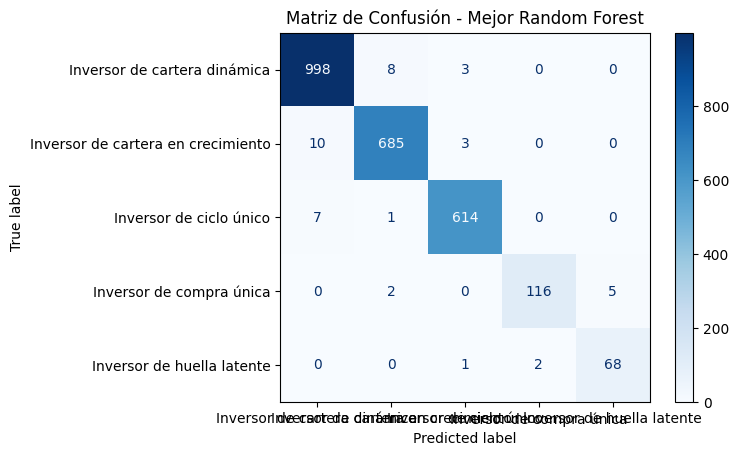

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'criterion': ['gini']
}


grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    verbose=2
)


print("Iniciando la búsqueda en rejilla...")
grid_search.fit(X_train_rf, y_train_rf)


print("\n--- Búsqueda Finalizada ---")
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor score en entrenamiento (CV): {grid_search.best_score_:.4f}")

# modelo ganador
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test_rf)

# Reporte de clasificación (Precisión, Recall, F1)
print("\n--- Reporte de Clasificación (Test) ---")
print(classification_report(y_test_rf, y_pred))

# Matriz de Confusión
print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test_rf, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matriz de Confusión - Mejor Random Forest")
plt.show()

XGBOOST

Iniciando la búsqueda en rejilla para XGBoost...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Mejores parámetros encontrados: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Mejor score en entrenamiento (CV): 0.9908

--- Reporte de Clasificación (Test) ---
                                    precision    recall  f1-score   support

      Inversor de cartera dinámica       0.99      1.00      0.99      1009
Inversor de cartera en crecimiento       1.00      0.99      0.99       698
           Inversor de ciclo único       1.00      0.99      0.99       622
          Inversor de compra única       0.99      1.00      1.00       123
        Inversor de huella latente       1.00      0.99      0.99        71

                          accuracy                           0.99      2523
                         macro avg       1.00      0.99      0.99      2523
                      weighted avg       0.99      0.99      0.99      2523


--- Matriz de Confusión ---


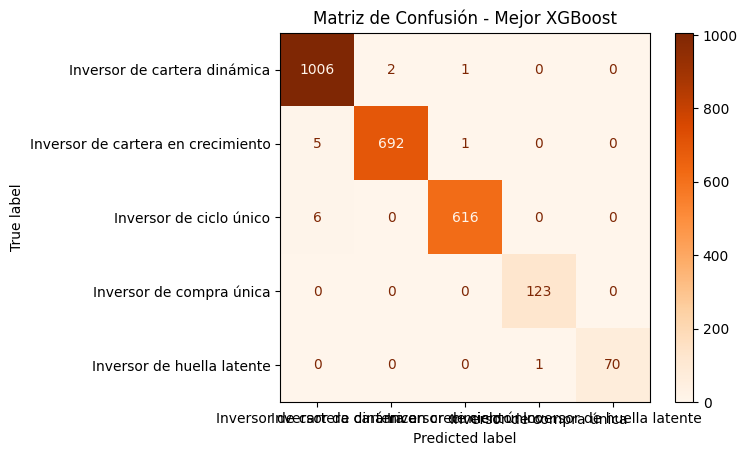

In [ ]:
X_xgb = X_final_rf.copy()
X_xgb.columns = (X_xgb.columns
                     .str.replace(r'\[', '', regex=True)
                     .str.replace(r'\]', '', regex=True)
                     .str.replace('<', '', regex=True)
                     .str.replace(' ', '_', regex=True))
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_xgb, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

xgb_base = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss')

# Rejilla
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5]
}

# Configuramos la búsqueda por rejilla
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print("Iniciando la búsqueda en rejilla para XGBoost...")
grid_search.fit(X_train, y_train)

# Evaluación del Mejor Modelo

print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor score en entrenamiento (CV): {grid_search.best_score_:.4f}")

# modelo ganador
best_xgb = grid_search.best_estimator_

y_pred = best_xgb.predict(X_test)

# Reporte de clasificación
print("\n--- Reporte de Clasificación (Test) ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Matriz de Confusión

print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Oranges)
plt.title("Matriz de Confusión - Mejor XGBoost")
plt.show()

CATBOOST

Variables categóricas:
['type_recodificado', 'cap_recodificada']
--- Búsqueda Finalizada ---
Mejores parámetros: {'depth': 6, 'iterations': 500, 'learning_rate': 0.1}
Mejor Macro F1 en CV: 0.9881

=== Classification Report (Test) ===
                                    precision    recall  f1-score   support

      Inversor de cartera dinámica       0.98      1.00      0.99      1009
Inversor de cartera en crecimiento       0.99      0.98      0.99       698
           Inversor de ciclo único       1.00      0.99      0.99       622
          Inversor de compra única       0.99      0.98      0.98       123
        Inversor de huella latente       0.97      0.99      0.98        71

                          accuracy                           0.99      2523
                         macro avg       0.99      0.99      0.99      2523
                      weighted avg       0.99      0.99      0.99      2523


Macro F1 Final en Test: 0.9861


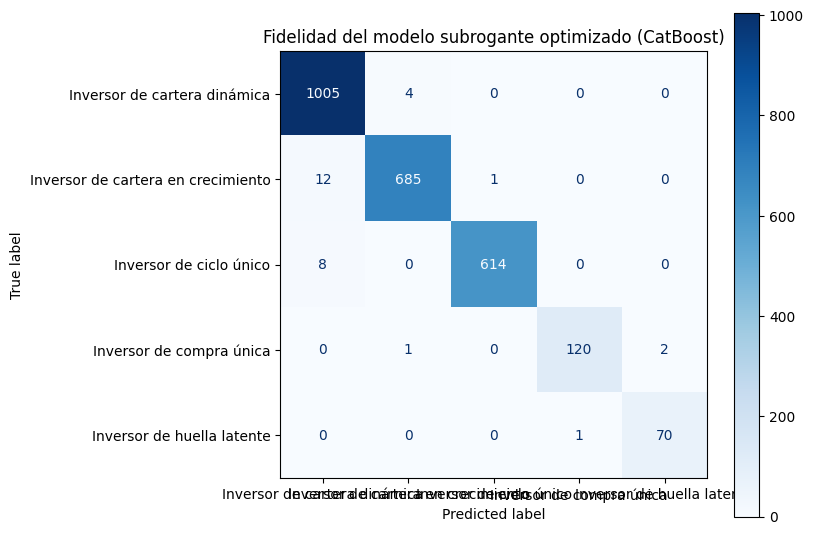

In [ ]:

X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_final_catboost, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

cat_features = X_train_cb.select_dtypes(
    include=['category']
).columns.tolist()

print("Variables categóricas:")
print(cat_features)

xct_base = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=False,
    thread_count=-1
)
param_grid = {
    'iterations': [300, 500],
    'depth': [6, 8],
    'learning_rate': [0.1]
}

grid_search = GridSearchCV(
    estimator=xct_base,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

# Rejilla
grid_search.fit(
    X_train_cb,
    y_train_cb,
    cat_features=cat_features
)

print("--- Búsqueda Finalizada ---")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor Macro F1 en CV: {grid_search.best_score_:.4f}")

surrogate_model = grid_search.best_estimator_


y_pred = surrogate_model.predict(X_test_cb).ravel()

#Evaluación

print("\n=== Classification Report (Test) ===")
print(
    classification_report(
        y_test_cb,
        y_pred,
        target_names=le.classes_
    )
)

from sklearn.metrics import f1_score
macro_f1 = f1_score(
    y_test_cb,
    y_pred,
    average='macro'
)
print(f"\nMacro F1 Final en Test: {macro_f1:.4f}")

# Matriz de confusión

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_cb,
    y_pred,
    ax=ax,
    cmap='Blues',
    display_labels=le.classes_
)

ax.set_title('Fidelidad del modelo subrogante optimizado (CatBoost)')
plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train_cb.copy()
for col in ['type_recodificado', 'cap_recodificada']:
    X_train[col] = X_train[col].astype('category')

cat_idx_for_catboost = [i for i, col in enumerate(X_train.columns)
                        if X_train[col].dtype.name == 'category']
print(f"Categorical feature indices: {cat_idx_for_catboost}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train_cb.shape}")

# Hiperparámetros
best_params = {
    'iterations': 500,
    'learning_rate': 0.1,
    'depth': 6,
    'loss_function': 'MultiClass',
    'eval_metric': 'Accuracy',
    'random_seed': 42,
    'verbose': 0,
    'thread_count': -1
}

n_classes = len(np.unique(y_train_cb))
print(f"Clases detectadas en entrenamiento: {n_classes} -> {sorted(np.unique(y_train_cb))}")

#  Validación Cruzada Estratificada sobre X_train

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
importancias_por_fold = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train_cb)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train_cb[train_idx], y_train_cb[val_idx]


    modelo_fold = CatBoostClassifier(
        **best_params,
        cat_features=cat_idx_for_catboost
    )
    modelo_fold.fit(X_tr, y_tr)


    pool_val = Pool(X_val, y_val, cat_features=cat_idx_for_catboost)

    # Obtener SHAP values multiclase
    shap_vals = modelo_fold.get_feature_importance(pool_val, type='ShapValues')

    #  Reestructurar SHAP values para multiclase

    n_features = X_train.shape[1]
    temp = shap_vals.reshape(-1, n_classes, n_features + 1)
    shap_features = temp[:, :, :-1]
    shap_array = np.transpose(shap_features, (0, 2, 1))

    # Importancia media absoluta por variable y clase
    imp_fold = np.mean(np.abs(shap_array), axis=0)
    importancias_por_fold.append(imp_fold)
    print(f"Fold {fold+1}/5 completado. SHAP shape: {shap_array.shape}")

importancia_media = np.mean(importancias_por_fold, axis=0)

nombres_clases_reales = sorted(modelo_log['segmento_final'].unique())

# Construcción del DataFrame
df_importancias = pd.DataFrame(
    importancia_media,
    index=X_train.columns,
    columns=nombres_clases_reales
)

# Añadir importancia global
df_importancias['Importancia_Global'] = df_importancias.mean(axis=1)
df_importancias = df_importancias.sort_values('Importancia_Global', ascending=False)

print("\n── Ranking de Importancia SHAP (CatBoost, multiclase, 5-Fold CV) ──")
print(df_importancias.round(4))

Categorical feature indices: [15, 16]
X_train shape: (10090, 17), y_train shape: (10090,)
Clases detectadas en entrenamiento: 5 -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Fold 1/5 completado. SHAP shape: (2018, 17, 5)
Fold 2/5 completado. SHAP shape: (2018, 17, 5)
Fold 3/5 completado. SHAP shape: (2018, 17, 5)
Fold 4/5 completado. SHAP shape: (2018, 17, 5)
Fold 5/5 completado. SHAP shape: (2018, 17, 5)

── Ranking de Importancia SHAP (CatBoost, multiclase, 5-Fold CV) ──
                          Inversor de cartera dinámica  \
activity_days                                   2.1409   
profit_std_buy                                  0.7043   
buy_sell_ratio                                  0.3676   
avg_days_between_ops                            0.3031   
risk_exposure                                   0.2970   
n_buy                                           0.4783   
recency_days                                    0.2474   
asset_diversification              

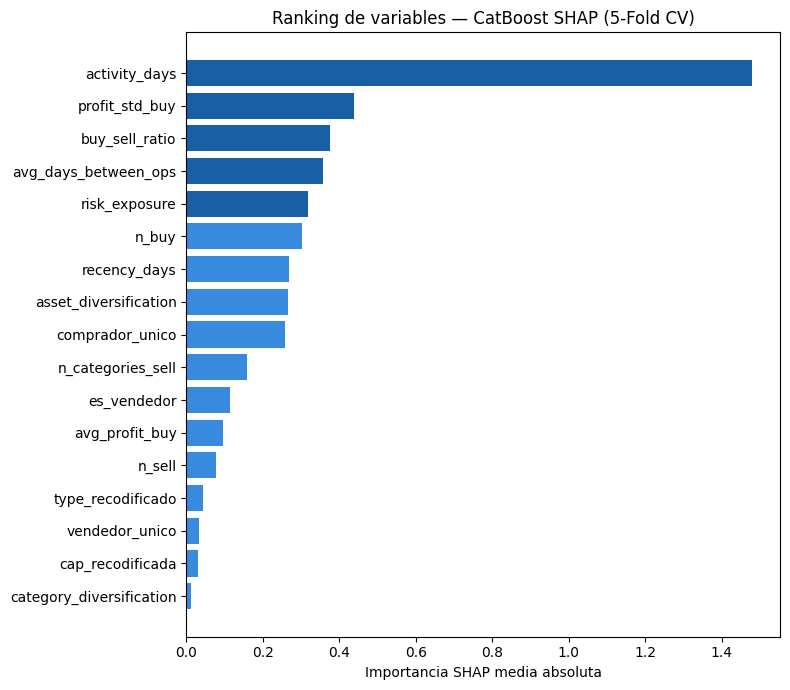

In [ ]:
top_n = df_importancias.head(20)
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#185FA5' if i < 5 else '#378ADD' for i in range(len(top_n))]
ax.barh(top_n.index[::-1], top_n['Importancia_Global'][::-1], color=colors[::-1])
ax.set_xlabel('Importancia SHAP media absoluta')
ax.set_title('Ranking de variables — CatBoost SHAP (5-Fold CV)')
plt.tight_layout()

Clases del modelo: [0 1 2 3 4]
Forma de shap_values: (10090, 17, 5)
Generando gráficos para activity_days...


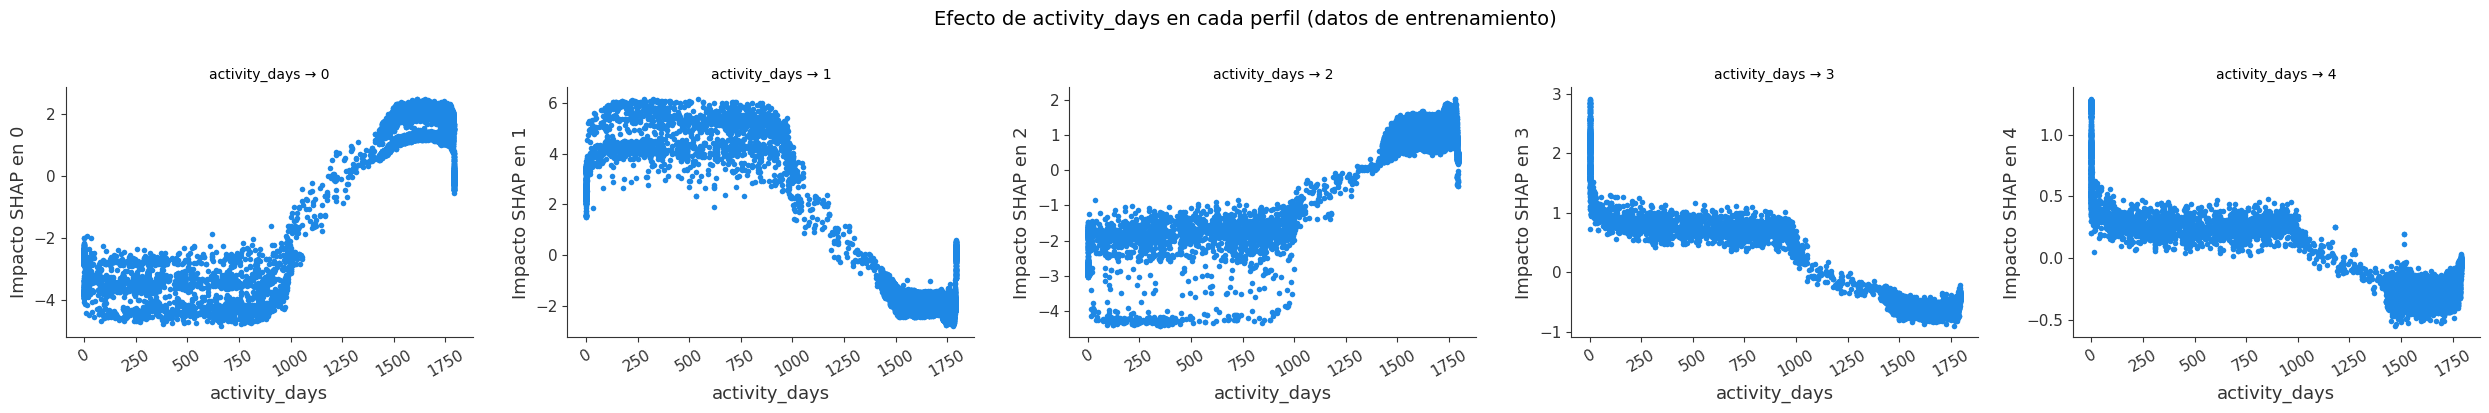

Generando gráficos para profit_std_buy...


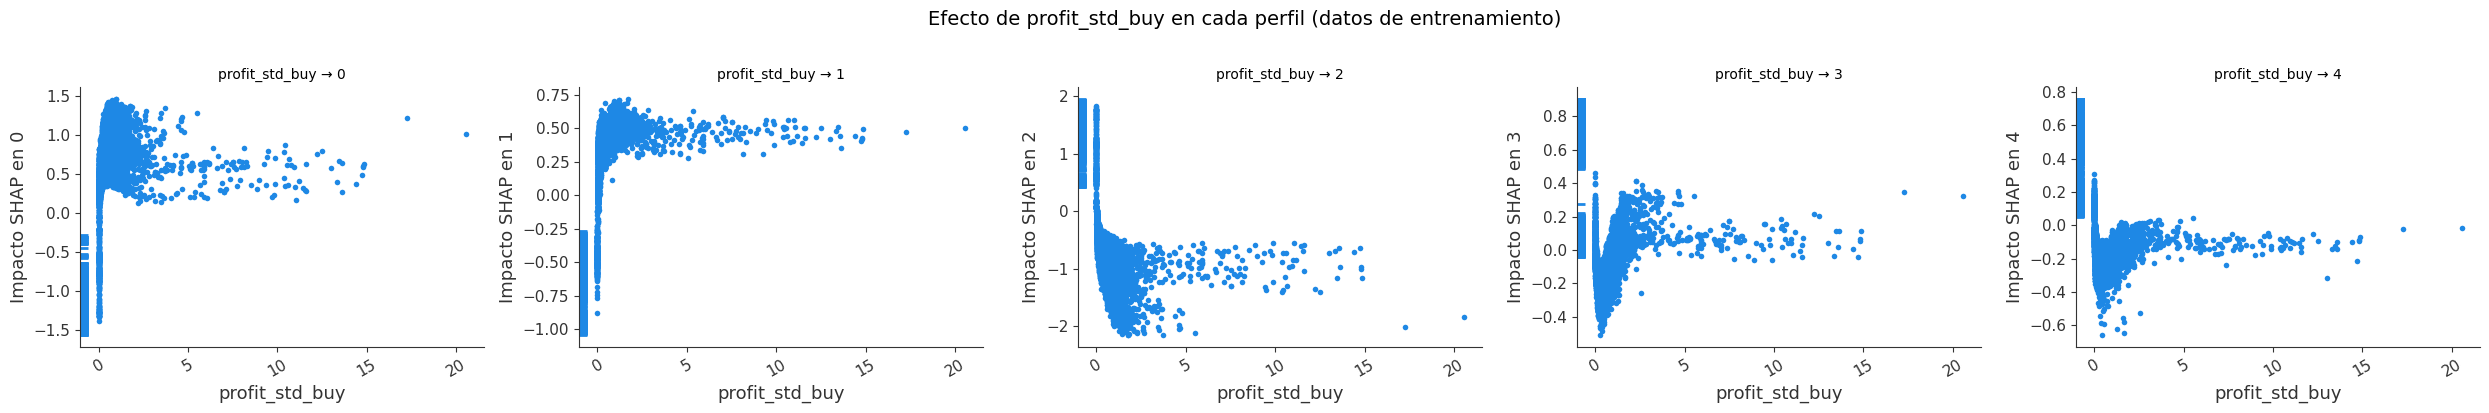

Generando gráficos para avg_days_between_ops...


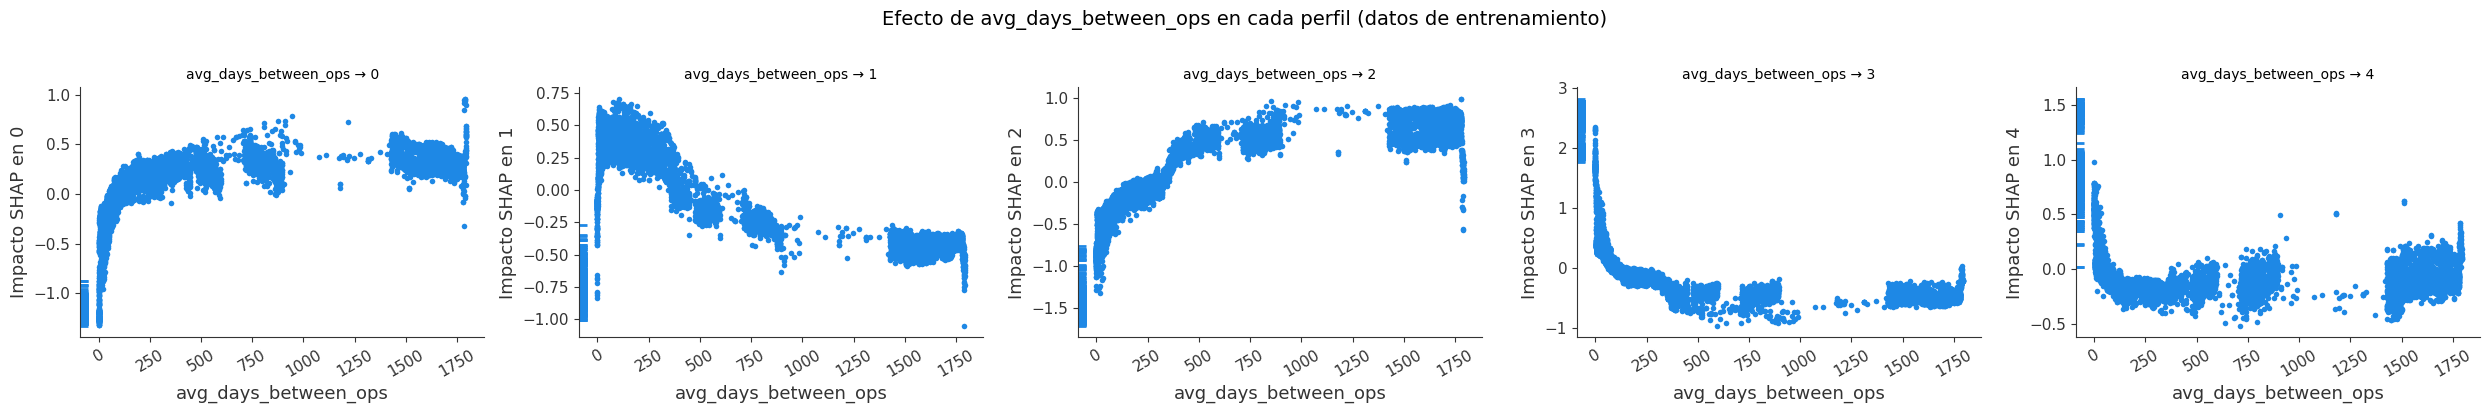

Generando gráficos para buy_sell_ratio...


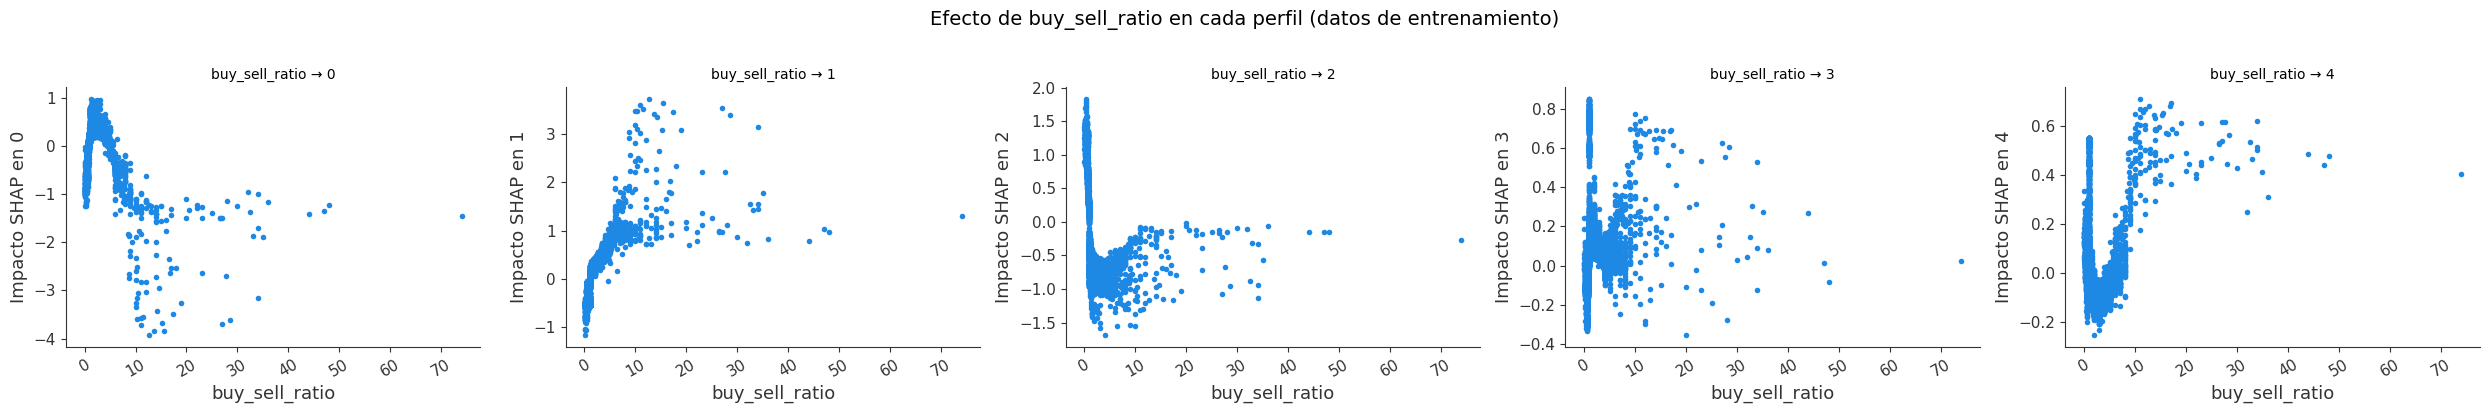

Generando gráficos para recency_days...


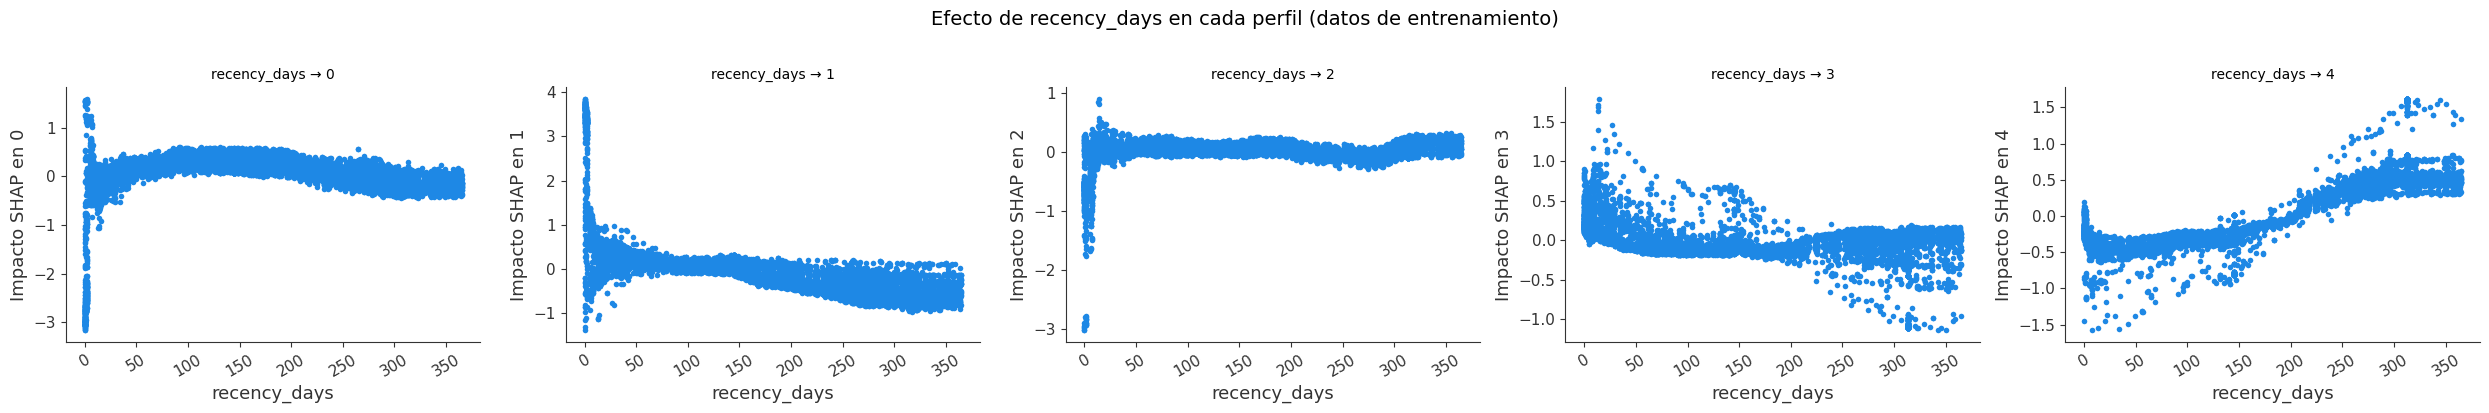

In [ ]:
X = X_train.copy()
y = y_train.copy()

for col in ['type_recodificado', 'cap_recodificada']:
    X[col] = X[col].astype('category')

cat_idx = [i for i, col in enumerate(X.columns) if X[col].dtype.name == 'category']

#  modelo final
best_params = {
    'iterations': 500,
    'learning_rate': 0.1,
    'depth': 8,
    'loss_function': 'MultiClass',
    'eval_metric': 'Accuracy',
    'random_seed': 42,
    'thread_count': -1
}

modelo_final = CatBoostClassifier(
    **best_params,
    cat_features=cat_idx,
    verbose=0
)
modelo_final.fit(X, y)
#  Extraer SHAP

pool_all = Pool(X, y, cat_features=cat_idx)
shap_raw = modelo_final.get_feature_importance(pool_all, type='ShapValues')

n_features = X.shape[1]
n_classes = len(modelo_final.classes_)


temp = shap_raw.reshape(-1, n_classes, n_features + 1)
shap_features = temp[:, :, :-1]
shap_values = np.transpose(shap_features, (0, 2, 1))

print("Clases del modelo:", modelo_final.classes_)
print("Forma de shap_values:", shap_values.shape)


vars_analizar = [
    'activity_days',
    'profit_std_buy',
    'avg_days_between_ops',
    'buy_sell_ratio',
    'recency_days'
]

for var in vars_analizar:
    if var not in X.columns:
        print(f"Variable {var} no encontrada en los datos. Se omite.")
        continue

    idx = X.columns.get_loc(var)
    print(f"Generando gráficos para {var}...")

    fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 4), sharey=False)
    if n_classes == 1:
        axes = [axes]

    for i, clase in enumerate(modelo_final.classes_):
        shap_vals_clase = shap_values[:, :, i]

        ax = axes[i]
        shap.dependence_plot(
            idx,
            shap_vals_clase,
            X,
            interaction_index=None,
            ax=ax,
            show=False
        )
        ax.set_title(f'{var} → {clase}', fontsize=10)
        ax.set_xlabel(var)
        ax.set_ylabel(f'Impacto SHAP en {clase}')
        ax.tick_params(axis='x', rotation=30)

    plt.suptitle(f'Efecto de {var} en cada perfil (datos de entrenamiento)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

FUNCIONES DE PERTENENCIA

In [ ]:
# Funciones de pertenencia (sigmoides)

def stable_sigmoid(z):
    exp_neg_abs = np.exp(-np.abs(z))
    return np.where(z >= 0,
                    1 / (1 + exp_neg_abs),
                    exp_neg_abs / (1 + exp_neg_abs))

def sigmoide_estable(x, c, s, creciente=True):
    z = (x - c) / s
    if creciente:
        return stable_sigmoid(z)
    else:
        # Decreciente
        return 1 - stable_sigmoid(z)

#  profit_std_buy

umbral_std = 0.2074
s_std = umbral_std / 10

def mu_std_bajo(x):
    return sigmoide_estable(x, umbral_std, s_std, creciente=False)

def mu_std_alto(x):

    return sigmoide_estable(x, umbral_std, s_std, creciente=True)

def mu_std_sin_dato(x):
    return np.where(np.isnan(x), 1.0, 0.0)

# buy_sell_ratio


s_buy_bajo  = 0.511  / 4
s_buy_medio = 0.511  / 8
s_buy_alto  = 1.9828 / 8

def mu_buy_bajo(x):
    return sigmoide_estable(x, 0.511, s_buy_bajo, creciente=False)

def mu_buy_medio(x):
    return np.maximum(0,
        sigmoide_estable(x, 0.55,   s_buy_medio, creciente=True)
      - sigmoide_estable(x, 1.9828, s_buy_medio, creciente=True)
    )

def mu_buy_alto(x):
    return sigmoide_estable(x, 1.9828, s_buy_alto, creciente=True)


# avg

s_avg_bajo  = 984.0 / 10
s_avg_medio = (1786.5 - 984.0) / 8
s_avg_alto  = 1786.5 / 10


def mu_avg_bajo(x):
    return np.maximum(0,
        sigmoide_estable(x, 0 + 2*s_avg_bajo, s_avg_bajo, creciente=True)
      - sigmoide_estable(x, 984.0, s_avg_bajo, creciente=True)
    )

def mu_avg_medio(x):
    return np.maximum(0,
        sigmoide_estable(x, 984.0 + 2*s_avg_medio, s_avg_medio, creciente=True)
      - sigmoide_estable(x, 1786.5, s_avg_medio, creciente=True)
    )

def mu_avg_alto(x):
    return sigmoide_estable(x, 1786.5, s_avg_alto, creciente=True)

def mu_avg_sin_dato(x):
    return np.where(np.isnan(x), 1.0, 0.0)


# activity_days

s_act_inm   = 1167.0 / 12
s_act_bajo  = 1167.0 / 10
s_act_medio = (1789.5 - 1167.0) / 8
s_act_alto  = 1789.5 / 10

def mu_act_inmediato(x):
    return sigmoide_estable(x, 0.5, s_act_inm, creciente=False)

def mu_act_bajo(x):
    return np.maximum(0,
        sigmoide_estable(x, 0.5  + 2*s_act_bajo,  s_act_bajo,  creciente=True)
      - sigmoide_estable(x, 1167.0,                s_act_bajo,  creciente=True)
    )

def mu_act_medio(x):
    return np.maximum(0,
        sigmoide_estable(x, 1167.0 + 2*s_act_medio, s_act_medio, creciente=True)
      - sigmoide_estable(x, 1789.5,                  s_act_medio, creciente=True)
    )

def mu_act_alto(x):
    return sigmoide_estable(x, 1789.5, s_act_alto, creciente=True)

#recency_days

s_rec_baja = 311.5 / 18
s_rec_alta = 311.5 / 18

def mu_rec_baja(x):
    return sigmoide_estable(x, 311.5, s_rec_baja, creciente=False)

def mu_rec_alta(x):
    return sigmoide_estable(x, 311.5, s_rec_alta, creciente=True)

GRAFICAS

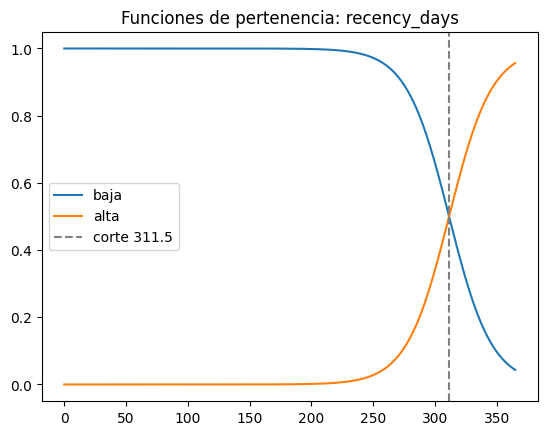

In [ ]:
x_zoom = np.linspace(0, 365, 500)
plt.plot(x_zoom, mu_rec_baja(x_zoom), label='baja')
plt.plot(x_zoom, mu_rec_alta(x_zoom), label='alta')
plt.axvline(311.5, color='gray', linestyle='--', label='corte 311.5')
plt.legend()
plt.title('Funciones de pertenencia: recency_days')
#plt.savefig("/content/drive/MyDrive/fp_rd.png",
            #dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

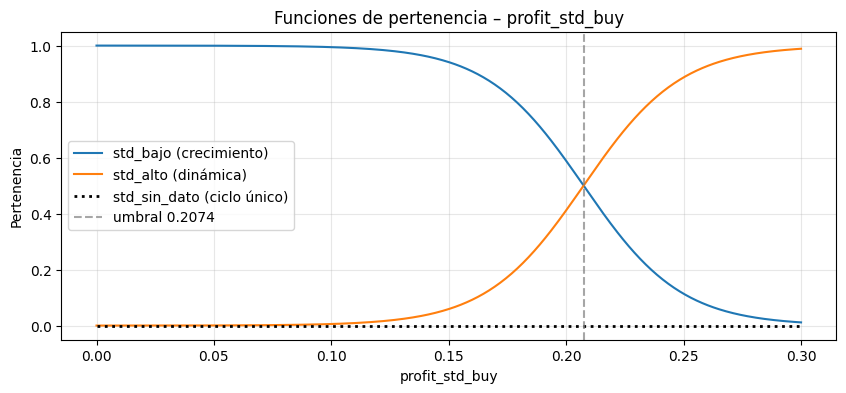

In [ ]:

x_zoom = np.linspace(0, 0.30, 500)

plt.figure(figsize=(10,4))
plt.plot(x_zoom, mu_std_bajo(x_zoom), label='std_bajo (crecimiento)')
plt.plot(x_zoom, mu_std_alto(x_zoom), label='std_alto (dinámica)')
plt.plot(x_zoom, mu_std_sin_dato(x_zoom), label='std_sin_dato (ciclo único)',
         linestyle=':', linewidth=2, color='black')
plt.axvline(umbral_std, color='gray', linestyle='--', alpha=0.7,
            label=f'umbral {umbral_std}')
plt.legend()
plt.title('Funciones de pertenencia – profit_std_buy')
plt.xlabel('profit_std_buy')
plt.ylabel('Pertenencia')
plt.grid(alpha=0.3)
#plt.savefig("/content/drive/MyDrive/fp_profit.png",
            #dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

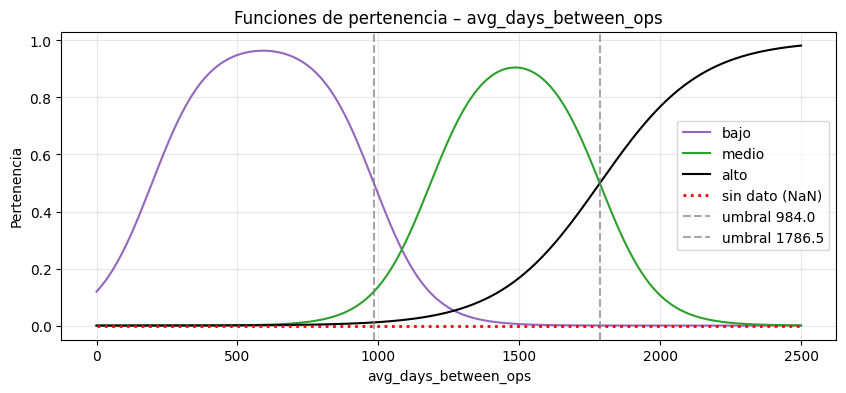

In [ ]:

x = np.linspace(0, 2500, 500)

plt.figure(figsize=(10,4))
plt.plot(x, mu_avg_bajo(x), label='bajo', color='tab:purple')
plt.plot(x, mu_avg_medio(x), label='medio', color='tab:green')
plt.plot(x, mu_avg_alto(x), label='alto', color='black')
plt.plot(x, mu_avg_sin_dato(x), label='sin dato (NaN)',
         linestyle=':', linewidth=2, color='red')

plt.axvline(984.0, color='gray', linestyle='--', alpha=0.7, label='umbral 984.0')
plt.axvline(1786.5, color='gray', linestyle='--', alpha=0.7, label='umbral 1786.5')

plt.legend()
plt.title('Funciones de pertenencia – avg_days_between_ops')
plt.xlabel('avg_days_between_ops')
plt.ylabel('Pertenencia')
plt.grid(alpha=0.3)
#plt.savefig("/content/drive/MyDrive/fp_avb.png",
            #dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

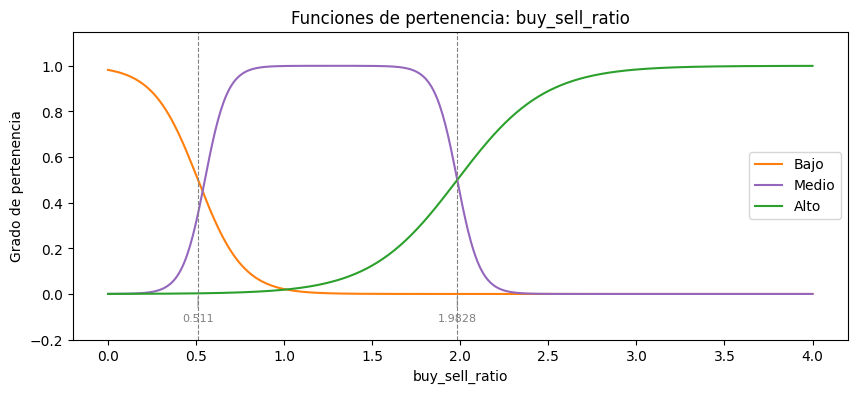

In [ ]:
x = np.linspace(0, 4, 500)
umbrales = [0.511, 1.9828]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(x, mu_buy_bajo(x),  label='Bajo',  color='tab:orange')
ax.plot(x, mu_buy_medio(x), label='Medio', color='tab:purple')
ax.plot(x, mu_buy_alto(x),  label='Alto',  color='tab:green')

for u in umbrales:
    ax.axvline(x=u, color='gray', linestyle='--', linewidth=0.8)
    ax.annotate(f'{u}', xy=(u, 0), xytext=(u, -0.12),
                ha='center', fontsize=8, color='gray',
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.6))

ax.set_ylim(-0.2, 1.15)
ax.legend()
ax.set_title('Funciones de pertenencia: buy_sell_ratio')
ax.set_xlabel('buy_sell_ratio')
ax.set_ylabel('Grado de pertenencia')
#plt.savefig("/content/drive/MyDrive/fp_bs.png",
            #dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

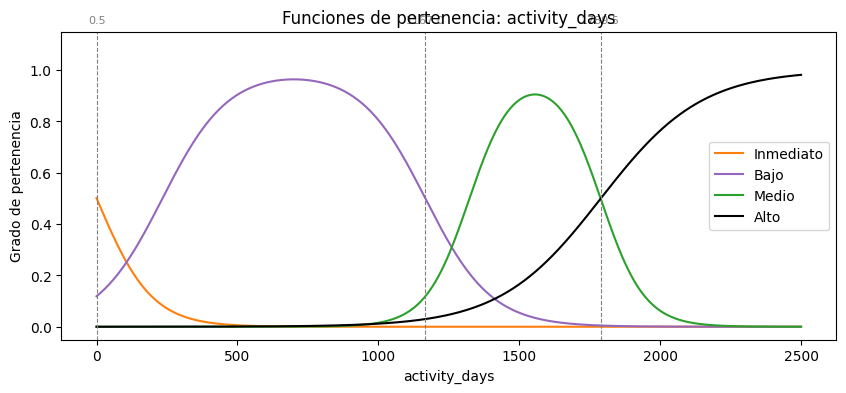

In [ ]:
x = np.linspace(0, 2500, 500)
umbrales = [0.5, 1167.0, 1789.5]

plt.figure(figsize=(10,4))
plt.plot(x, mu_act_inmediato(x), label='Inmediato', color='tab:orange')
plt.plot(x, mu_act_bajo(x),      label='Bajo',      color='tab:purple')
plt.plot(x, mu_act_medio(x),     label='Medio',     color='tab:green')
plt.plot(x, mu_act_alto(x),      label='Alto',      color='black')

for u in umbrales:
    plt.axvline(x=u, color='gray', linestyle='--', linewidth=0.8)
    plt.text(u, 1.02, f'{u}', ha='center', va='bottom',
             fontsize=8, color='gray', transform=plt.gca().get_xaxis_transform())

plt.ylim(-0.05, 1.15)
plt.legend()
plt.title('Funciones de pertenencia: activity_days')
plt.xlabel('activity_days')
plt.ylabel('Grado de pertenencia')
#plt.savefig("/content/drive/MyDrive/fp_act.png",
            #dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

CLASIFICADOR BORROSO WANG MENDEL

In [ ]:

def fuzzificar(x, funciones_dict):

    if np.isnan(x):

        for term in funciones_dict:
            if 'sin_dato' in term.lower():
                return term, 1.0
        raise ValueError("x es NaN pero no hay un término 'sin_dato' en el diccionario.")

    grados = {termino: float(f(np.array([x])))
              for termino, f in funciones_dict.items()}
    dominante = max(grados, key=grados.get)
    return dominante, grados[dominante]

# Diccionarios de funciones

fuzzy_profit_std = {
    'std_bajo':     mu_std_bajo,
    'std_alto':     mu_std_alto,
    'std_sin_dato': mu_std_sin_dato
}

fuzzy_buy_sell = {
    'bajo':  mu_buy_bajo,
    'medio': mu_buy_medio,
    'alto':  mu_buy_alto
}

fuzzy_avg_days = {
    'bajo':      mu_avg_bajo,
    'medio':     mu_avg_medio,
    'alto':      mu_avg_alto,
    'sin_dato':  mu_avg_sin_dato
}

fuzzy_activity = {
    'inmediato': mu_act_inmediato,
    'bajo':      mu_act_bajo,
    'medio':     mu_act_medio,
    'alto':      mu_act_alto
}

fuzzy_recency = {
    'baja': mu_rec_baja,
    'alta': mu_rec_alta
}

In [ ]:
def generar_reglas_5vars(X, y, tnorma='producto'):
    reglas = {}
    for idx, row in X.iterrows():

        t_profit, g_profit = fuzzificar(row['profit_std_buy'],       fuzzy_profit_std)
        t_buy,    g_buy    = fuzzificar(row['buy_sell_ratio'],        fuzzy_buy_sell)
        t_avg,    g_avg    = fuzzificar(row['avg_days_between_ops'],  fuzzy_avg_days)
        t_act,    g_act    = fuzzificar(row['activity_days'],         fuzzy_activity)
        t_rec,    g_rec    = fuzzificar(row['recency_days'],          fuzzy_recency)

        antecedente = (t_profit, t_buy, t_avg, t_act, t_rec)

        # t-norma
        if tnorma == 'producto':
            grado = g_profit * g_buy * g_avg * g_act * g_rec
        else:
            grado = min(g_profit, g_buy, g_avg, g_act, g_rec)

        consecuente = y.iloc[idx]

        # Acumular votos por antecedente
        if antecedente not in reglas:
            reglas[antecedente] = {consecuente: grado}
        else:
            if consecuente in reglas[antecedente]:
                reglas[antecedente][consecuente] += grado
            else:
                reglas[antecedente][consecuente] = grado

    # Para cada antecedente, quedarse con la clase más votada
    reglas_finales = {}
    for antecedente, votos in reglas.items():
        ganador = max(votos, key=votos.get)
        reglas_finales[antecedente] = (ganador, votos[ganador])

    return reglas_finales

In [ ]:
def clasificar_5vars(row, reglas):
    t_profit, g_profit = fuzzificar(row['profit_std_buy'],       fuzzy_profit_std)
    t_buy,    g_buy    = fuzzificar(row['buy_sell_ratio'],        fuzzy_buy_sell)
    t_avg,    g_avg    = fuzzificar(row['avg_days_between_ops'],  fuzzy_avg_days)
    t_act,    g_act    = fuzzificar(row['activity_days'],         fuzzy_activity)
    t_rec,    g_rec    = fuzzificar(row['recency_days'],          fuzzy_recency)

    antecedente = (t_profit, t_buy, t_avg, t_act, t_rec)

    if antecedente in reglas:
        return reglas[antecedente][0]
    return None

In [ ]:
y = modelo_log['segmento_final']

# Encodear
le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(y), index=y.index)

FEATURES_DIFUSAS = [
    'activity_days',
    'profit_std_buy',
    'avg_days_between_ops',
    'buy_sell_ratio',
    'recency_days'
]

# Split
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_final_catboost, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train_dif = X_train_cb[FEATURES_DIFUSAS].copy().reset_index(drop=True)
X_test_dif  = X_test_cb[FEATURES_DIFUSAS].copy().reset_index(drop=True)
y_train_dif = y_train_cb.reset_index(drop=True)
y_test_dif  = y_test_cb.reset_index(drop=True)

In [ ]:
reglas_5v = generar_reglas_5vars(X_train_dif, y_train_dif, tnorma='producto')
print(f"Total reglas generadas: {len(reglas_5v)}")

y_pred = []
for idx, row in X_test_dif.iterrows():
    pred = clasificar_5vars(row, reglas_5v)
    if pred is None:
        pred = y_train_dif.mode()[0]
    y_pred.append(pred)

print(classification_report(y_test_dif , y_pred))

/tmp/ipykernel_5267/2804903065.py:13: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



Total reglas generadas: 67


/tmp/ipykernel_5267/2804903065.py:13: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1009
           1       0.98      0.98      0.98       698
           2       1.00      0.97      0.98       622
           3       0.85      0.72      0.78       123
           4       0.62      0.75      0.68        71

    accuracy                           0.96      2523
   macro avg       0.88      0.88      0.88      2523
weighted avg       0.96      0.96      0.96      2523



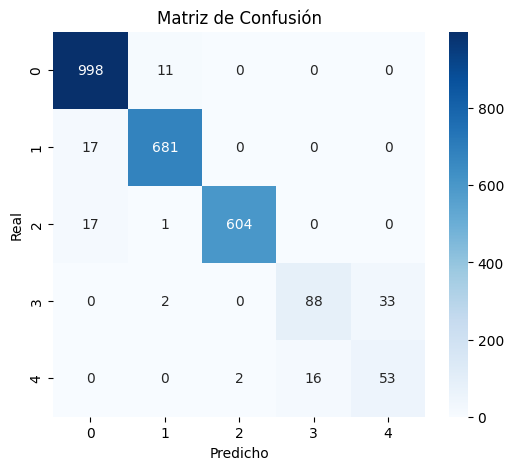

In [ ]:
cm = confusion_matrix(y_test_dif, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test_dif.unique()),
            yticklabels=sorted(y_test_dif.unique()))
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.savefig("/content/drive/MyDrive/MC_difuso.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
reglas_df = pd.DataFrame([
    {
        'profit': ant[0],
        'buy_sell': ant[1],
        'avg_days': ant[2],
        'activity': ant[3],
        'recency': ant[4],
        'clase': clase,
        'peso': peso
    }
    for ant, (clase, peso) in reglas_5v.items()
])

# Ordena por peso descendente para ver las reglas con más respaldo
reglas_df.sort_values('peso', ascending=False, inplace=True)
print(reglas_df.head(20))

# Estadísticas por clase
print(reglas_df.groupby('clase').agg(
    num_reglas=('peso', 'count'),
    peso_medio=('peso', 'mean'),
    peso_max=('peso', 'max'),
    peso_min=('peso', 'min')
))

          profit buy_sell  avg_days   activity recency  clase        peso
2   std_sin_dato     bajo     medio      medio    baja      2  624.253965
4       std_alto    medio      bajo      medio    baja      0  542.348124
8       std_bajo    medio      bajo      medio    baja      0  203.113253
5   std_sin_dato    medio  sin_dato  inmediato    baja      3  180.989035
12      std_bajo     alto      bajo       bajo    baja      1  166.457002
0       std_alto    medio     medio      medio    baja      0  154.139664
6       std_alto     alto      bajo      medio    baja      0  103.833119
3   std_sin_dato     bajo     medio      medio    alta      2   97.637995
22      std_bajo    medio     medio      medio    baja      0   93.448208
14  std_sin_dato     bajo      bajo      medio    baja      2   92.691698
7       std_alto     alto      bajo       bajo    baja      1   78.848026
17      std_bajo    medio      bajo       bajo    baja      1   77.295010
11      std_alto    medio      bajo   

/tmp/ipykernel_5267/553743298.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_5267/553743298.py:28: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



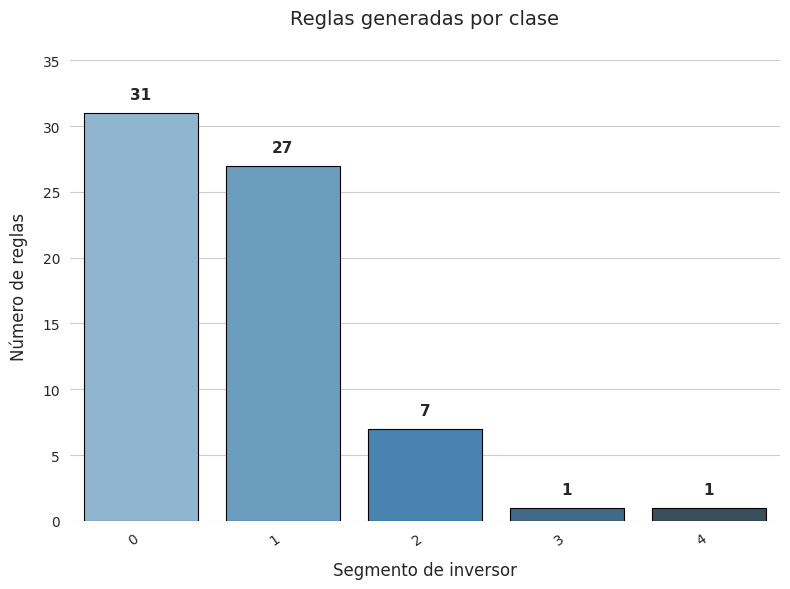

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
conteo = reglas_df['clase'].value_counts().reset_index()
conteo.columns = ['Segmento', 'Número de reglas']
colores = sns.color_palette("Blues_d", len(conteo))
fig, ax = plt.subplots(figsize=(8, 6))
barras = sns.barplot(
    data=conteo,
    x='Segmento',
    y='Número de reglas',
    palette=colores,
    edgecolor='black',
    linewidth=0.8,
    ax=ax
)
for barra in barras.patches:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.8,
        f'{int(altura)}',
        ha='center', va='bottom',
        fontweight='bold', fontsize=11
    )
ax.set_xlabel('Segmento de inversor', fontsize=12, labelpad=10)
ax.set_ylabel('Número de reglas', fontsize=12, labelpad=10)
ax.set_title('Reglas generadas por clase', fontsize=14, pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.set_ylim(0, max(conteo['Número de reglas']) * 1.15)  # margen superior para etiquetas


sns.despine(left=True, bottom=True)

plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/reglas.png",
           #dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
def perfil_con_porcentajes(df_clase):
    perfil = {}
    soporte = {}
    total = len(df_clase)
    for col in ['profit', 'buy_sell', 'avg_days', 'activity', 'recency']:
        conteo = df_clase[col].value_counts(normalize=True) * 100
        termino_dominante = conteo.idxmax()
        porcentaje = conteo.max()
        perfil[col] = termino_dominante
        soporte[col] = f"{porcentaje:.0f}%"
    return perfil, soporte

perfiles_dominantes = {}
soportes = {}
for clase in reglas_df['clase'].unique():
    df_clase = reglas_df[reglas_df['clase'] == clase]
    perfil, soporte = perfil_con_porcentajes(df_clase)
    perfiles_dominantes[clase] = perfil
    soportes[clase] = soporte

# Convertir a DataFrame para presentar
perfiles_df = pd.DataFrame(perfiles_dominantes).T
soportes_df = pd.DataFrame(soportes).T

mapa_nombres = dict(enumerate(le.classes_))

perfiles_df.index = perfiles_df.index.map(mapa_nombres)
soportes_df.index = soportes_df.index.map(mapa_nombres)

print("Perfil dominante (término más frecuente):")
print(perfiles_df)
print("\nPorcentaje de reglas que respaldan cada término:")
print(soportes_df)

Perfil dominante (término más frecuente):
                                          profit buy_sell  avg_days  \
Inversor de ciclo único             std_sin_dato     bajo     medio   
Inversor de cartera dinámica            std_bajo    medio      bajo   
Inversor de compra única            std_sin_dato    medio  sin_dato   
Inversor de cartera en crecimiento      std_alto     alto      bajo   
Inversor de huella latente          std_sin_dato    medio  sin_dato   

                                     activity recency  
Inversor de ciclo único                 medio    baja  
Inversor de cartera dinámica            medio    baja  
Inversor de compra única            inmediato    baja  
Inversor de cartera en crecimiento       bajo    baja  
Inversor de huella latente          inmediato    alta  

Porcentaje de reglas que respaldan cada término:
                                   profit buy_sell avg_days activity recency
Inversor de ciclo único              100%     100%      57%      71%